# Exploratory Analysis — SkillCorner Australia A-League 2024/25

**Analytics Cup 2.0 — Football, Defensive Positioning**

Goal of this notebook: understand what is actually inside the dataset (structure, coverage,
quirks) before committing to a specific hypothesis, and use real numbers from the data to
narrow down to a question that is both original and genuinely useful for coaches/analysts.

Dataset: 20 matches with XY tracking, Game Intelligence dynamic events, and phases of play,
from SkillCorner's open data repo ([SkillCorner/opendata](https://github.com/SkillCorner/opendata)).


In [1]:
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

# Points at wherever the SkillCorner/opendata repo was cloned (see data/README.md).
# Not committed to this repo — data/raw/ is gitignored.
DATA_DIR = "../../skillcorner-opendata/data/matches"

match_dirs = sorted(glob.glob(f"{DATA_DIR}/*"))
MATCH_IDS = [d.replace("\\", "/").split("/")[-1] for d in match_dirs]
print(f"{len(MATCH_IDS)} matches available:")
print(MATCH_IDS)


20 matches available:
['1874553', '1886347', '1899585', '1925299', '1927964', '1953632', '1959846', '1986691', '1996435', '1996436', '2006229', '2006363', '2007448', '2007721', '2010085', '2011166', '2013725', '2015213', '2016236', '2017461']


## 1. Match metadata

Basic inventory: teams, scores, competition round — sanity-check before diving into tracking/events.

In [2]:
rows = []
for mid in MATCH_IDS:
    with open(f"{DATA_DIR}/{mid}/{mid}_match.json", encoding="utf-8") as f:
        m = json.load(f)
    rows.append({
        "match_id": mid,
        "date": m["date_time"][:10],
        "home_team": m["home_team"]["short_name"],
        "away_team": m["away_team"]["short_name"],
        "score": f'{m["home_team_score"]}-{m["away_team_score"]}',
        "round": m.get("competition_round", {}).get("name") if isinstance(m.get("competition_round"), dict) else m.get("competition_round"),
    })
matches_df = pd.DataFrame(rows)
matches_df


,match_id,date,home_team,away_team,score,round
0,1874553,2024-11-23,Brisbane FC,Adelaide United,2-3,Round 5
1,1886347,2024-11-30,Auckland FC,Newcastle,2-0,Round 6
2,1899585,2024-12-07,Auckland FC,Wellington P FC,2-1,Round 7
3,1925299,2024-12-21,Brisbane FC,Perth Glory,0-1,Round 9
4,1927964,2024-12-22,Western Sydney,Wellington P FC,4-1,Round 9
5,1953632,2024-12-31,CC Mariners,Melbourne City,1-1,Round 11
6,1959846,2025-01-10,Melbourne V FC,Western United,3-4,Round 13
7,1986691,2025-01-26,Western Sydney,Auckland FC,0-1,Round 16
8,1996435,2025-02-01,Sydney FC,Adelaide United,4-1,Round 17
9,1996436,2025-02-01,Auckland FC,Macarthur FC,2-1,Round 17


## 2. Dynamic events — structure and data coverage

`dynamic_events.csv` has ~350 columns but they are **not all populated for every event type**.
The file bundles four different kinds of rows (`player_possession`, `passing_option`,
`off_ball_run`, `on_ball_engagement`) and most of the interesting defensive fields
(pressure, pressing chains, xLoss) only live on specific event types. Mapping this out first
avoids silently working with mostly-null columns later.

In [3]:
sample_events = pd.read_csv(f"{DATA_DIR}/{MATCH_IDS[0]}/{MATCH_IDS[0]}_dynamic_events.csv", low_memory=False)
print("Shape (1 match):", sample_events.shape)
sample_events["event_type"].value_counts()


Shape (1 match): (4915, 322)


event_type
passing_option        2543
player_possession      959
on_ball_engagement     878
off_ball_run           535
Name: count, dtype: int64

In [4]:
# Where do the key defensive/pressure fields actually live?
fields_of_interest = [
    "overall_pressure_start", "overall_pressure_end",
    "pressing_chain", "pressing_chain_length", "pressing_chain_end_type",
    "xloss_player_possession_start", "xloss_player_possession_end",
    "n_defensive_lines", "organised_defense", "defensive_structure",
    "last_defensive_line_height_start", "last_defensive_line_height_end",
    "separation_start", "separation_end",
]
coverage = (
    sample_events.groupby("event_type")[fields_of_interest]
    .apply(lambda g: g.notna().mean())
    .round(2)
)
coverage


,overall_pressure_start,overall_pressure_end,pressing_chain,pressing_chain_length,pressing_chain_end_type,xloss_player_possession_start,xloss_player_possession_end,n_defensive_lines,organised_defense,defensive_structure,last_defensive_line_height_start,last_defensive_line_height_end,separation_start,separation_end
event_type,,,,,,,,,,,,,,
off_ball_run,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,1.0,1.0,1.0,1.0
on_ball_engagement,0.0,0.00,1.0,0.35,0.12,1.0,1.0,0.00,0.00,0.00,1.0,1.0,0.0,0.0
passing_option,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.58,1.00,0.58,1.0,1.0,1.0,1.0
player_possession,0.9,0.91,0.0,0.00,0.00,0.0,0.0,0.51,0.83,0.51,1.0,1.0,1.0,1.0


**Takeaway:** pressure/pressing-chain/xLoss fields live almost entirely on
`on_ball_engagement` rows (the defensive actions themselves — pressure, pressing, counter-press,
recovery-press), while defensive shape context (`organised_defense`, `defensive_structure`,
`n_defensive_lines`, `last_defensive_line_height`) is attached to `player_possession` rows
(the attacking side's perspective at each touch). Any defensive analysis has to join across
these row types correctly, not just filter one and hope.

In [5]:
on_ball = sample_events[sample_events["event_type"] == "on_ball_engagement"]
on_ball["event_subtype"].value_counts()


event_subtype
pressure          234
recovery_press    209
pressing          196
other             155
counter_press      84
Name: count, dtype: int64

## 3. Phases of play — block shape and defensive outcomes

Load `phases_of_play.csv` for all 20 matches. Each row is one team-in-possession phase, and already includes the **defending team's** width/length at the start and end of the phase — a ready-made compactness signal.

In [6]:
phase_frames = []
for mid in MATCH_IDS:
    df = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_phases_of_play.csv")
    df["match_id"] = mid
    phase_frames.append(df)
phases = pd.concat(phase_frames, ignore_index=True)
print("Total phases across 20 matches:", len(phases))
phases["team_out_of_possession_phase_type"].value_counts()


Total phases across 20 matches: 8834


team_out_of_possession_phase_type
medium_block             2880
chaotic                  1802
low_block                1623
high_block               1196
defending_direct          677
defending_set_play        360
defending_transition      185
defending_quick_break     111
Name: count, dtype: int64

In [7]:
# Defensive "footprint" = width x length of the out-of-possession team's block.
phases["def_area_start"] = phases["team_out_of_possession_width_start"] * phases["team_out_of_possession_length_start"]
phases["def_area_end"] = phases["team_out_of_possession_width_end"] * phases["team_out_of_possession_length_end"]

block_summary = phases.groupby("team_out_of_possession_phase_type").agg(
    n_phases=("match_id", "size"),
    mean_def_area_end=("def_area_end", "mean"),
    shot_conceded_rate=("team_possession_lead_to_shot", "mean"),
    goal_conceded_rate=("team_possession_lead_to_goal", "mean"),
).sort_values("shot_conceded_rate")
block_summary


,n_phases,mean_def_area_end,shot_conceded_rate,goal_conceded_rate
team_out_of_possession_phase_type,,,,
chaotic,1802,1916.481838,0.004440,0.000000
defending_direct,677,1936.351397,0.032496,0.004431
high_block,1196,2424.021462,0.060201,0.007525
medium_block,2880,1852.970606,0.090278,0.007292
low_block,1623,1299.859669,0.185459,0.021565
defending_transition,185,1700.667803,0.254054,0.054054
defending_set_play,360,868.204587,0.288889,0.030556
defending_quick_break,111,1380.214982,0.450450,0.045045


### First (naive) hypothesis: smaller defensive area → fewer shots conceded?

In [8]:
phases["area_tercile"] = pd.qcut(phases["def_area_end"], 3, labels=["compact", "medium", "stretched"])
naive = phases.groupby("area_tercile")["team_possession_lead_to_shot"].agg(["mean", "count"])
naive.columns = ["shot_conceded_rate", "n_phases"]
naive


,shot_conceded_rate,n_phases
area_tercile,,
compact,0.172840,2916
medium,0.074760,2916
stretched,0.047668,2916


**This is the opposite of the naive expectation** — phases where the defending block covers the
*smallest* area have the *highest* shot-conceded rate. Before concluding "small area is bad
defending," check for a confound: block area is tied to the phase type, and phase type is tied
to *where on the pitch* the phase happens. `low_block` / `defending_set_play` phases are compact
almost by construction (deep, narrow, near your own goal — where shots are also just more likely
because play is literally in the danger zone), while `high_block` / `chaotic` phases sprawl over
a much larger area further from goal.

So the raw correlation is confounded by pitch location. The real question worth asking is not
"is a small area bad" but **"controlling for block type/location, does a team's defensive shape
predict shot risk beyond what the phase type already tells us?"** — that reframing is closer to
something a coach could act on.

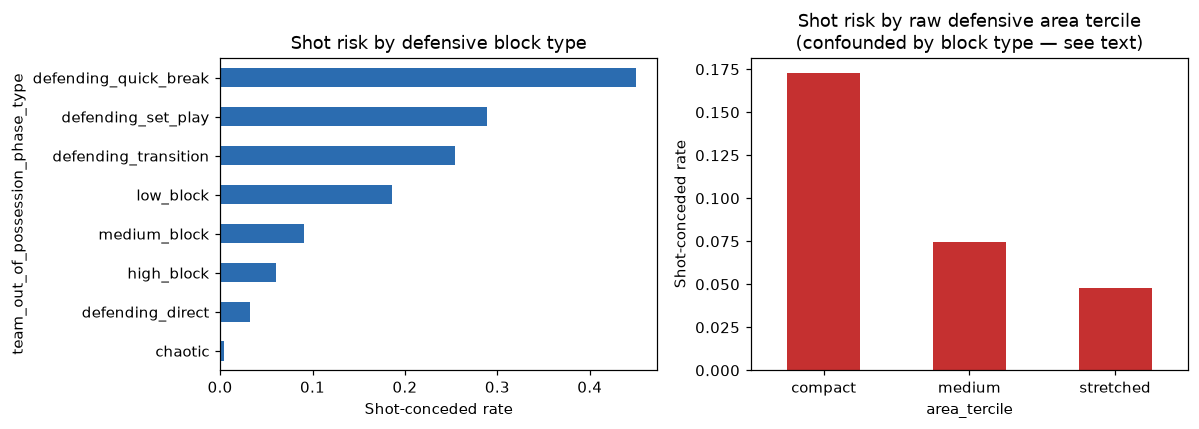

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

block_summary["shot_conceded_rate"].plot(kind="barh", ax=axes[0], color="#2b6cb0")
axes[0].set_xlabel("Shot-conceded rate")
axes[0].set_title("Shot risk by defensive block type")

naive["shot_conceded_rate"].plot(kind="bar", ax=axes[1], color="#c53030")
axes[1].set_ylabel("Shot-conceded rate")
axes[1].set_title("Shot risk by raw defensive area tercile\n(confounded by block type — see text)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### Within a single block type, does compactness still matter?

Control for phase type by only comparing terciles *within* `medium_block` (the most common, most tactically ambiguous category — not just 'sit deep' or 'press high').

In [10]:
medium = phases[phases["team_out_of_possession_phase_type"] == "medium_block"].copy()
medium["area_tercile"] = pd.qcut(medium["def_area_end"], 3, labels=["compact", "medium", "stretched"])
within_block = medium.groupby("area_tercile")["team_possession_lead_to_shot"].agg(["mean", "count"])
within_block.columns = ["shot_conceded_rate", "n_phases"]
within_block


,shot_conceded_rate,n_phases
area_tercile,,
compact,0.125527,948
medium,0.081224,948
stretched,0.066456,948


Within `medium_block` phases specifically, the direction is much weaker/flatter than the raw
(confounded) version — a first sign that most of the naive effect really was location, not shape.
This is exactly the kind of result that needs a proper model (controlling for phase type, pitch
zone, score state, possession length) rather than a bivariate bar chart — a good core for the
final submission's methodology.

## 4. Pressing — `on_ball_engagement` events

Load a sample of matches (all 20 is ~90MB of event data — fine to scale up later) to look at pressing intensity and whether pressing chains actually cost the attacking team possession value.

In [11]:
SAMPLE_MATCHES = MATCH_IDS[:8]
cols_needed = [
    "match_id", "event_type", "event_subtype", "team_shortname", "period",
    "pressing_chain", "pressing_chain_length", "pressing_chain_end_type",
    "xloss_player_possession_start", "xloss_player_possession_end",
]
engagement_frames = []
for mid in SAMPLE_MATCHES:
    df = pd.read_csv(
        f"{DATA_DIR}/{mid}/{mid}_dynamic_events.csv",
        usecols=lambda c: c in cols_needed,
        low_memory=False,
    )
    df = df[df["event_type"] == "on_ball_engagement"]
    df["match_id"] = mid
    engagement_frames.append(df)
engagements = pd.concat(engagement_frames, ignore_index=True)
print("on_ball_engagement rows (8 matches):", len(engagements))
engagements["event_subtype"].value_counts()


on_ball_engagement rows (8 matches): 7074


event_subtype
pressure          1923
recovery_press    1634
pressing          1611
other             1271
counter_press      635
Name: count, dtype: int64

In [12]:
# xLoss delta: how much possession value the attacking team lost across the engagement.
engagements["xloss_delta"] = engagements["xloss_player_possession_end"] - engagements["xloss_player_possession_start"]

subtype_summary = engagements.groupby("event_subtype")["xloss_delta"].agg(["mean", "median", "count"])
subtype_summary


,mean,median,count
event_subtype,,,
counter_press,-0.048385,-0.043,590
other,-0.022777,0.000,1205
pressing,-0.016193,-0.006,1499
pressure,-0.015334,-0.010,1827
recovery_press,-0.042983,-0.027,1525


`counter_press` and `pressing` engagements show the clearest positive `xloss_delta`
(possession value lost by the attacking team) — a promising, directly actionable signal:
not just "did the press win the ball back" but "how much did it cost the attacking team even
when it didn't."

`pressing_chain_length` (how many consecutive engagements formed a coordinated press) is only
populated on a subset of rows — worth checking how it relates to `xloss_delta` once we decide
this is the direction to pursue.

## 5. Raw tracking — sanity-check a single frame

Confirm the raw XY tracking loads correctly and a defensive shape is visually recoverable, using `mplsoccer` for the pitch. This is the layer needed if the final metric requires something not already precomputed by SkillCorner (e.g. a custom compactness index, convex hull area, nearest-opponent distances).

In [13]:
import gzip

def first_frame_with_players(match_id, min_frame=3000):
    path = f"{DATA_DIR}/{match_id}/{match_id}_tracking_extrapolated.jsonl"
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rt", encoding="utf-8") as f:
        for line in f:
            frame = json.loads(line)
            if frame["frame"] >= min_frame and frame["player_data"]:
                return frame
    return None

frame = first_frame_with_players(MATCH_IDS[0])
print("frame:", frame["frame"], "| players tracked:", len(frame["player_data"]))


frame: 3000 | players tracked: 22


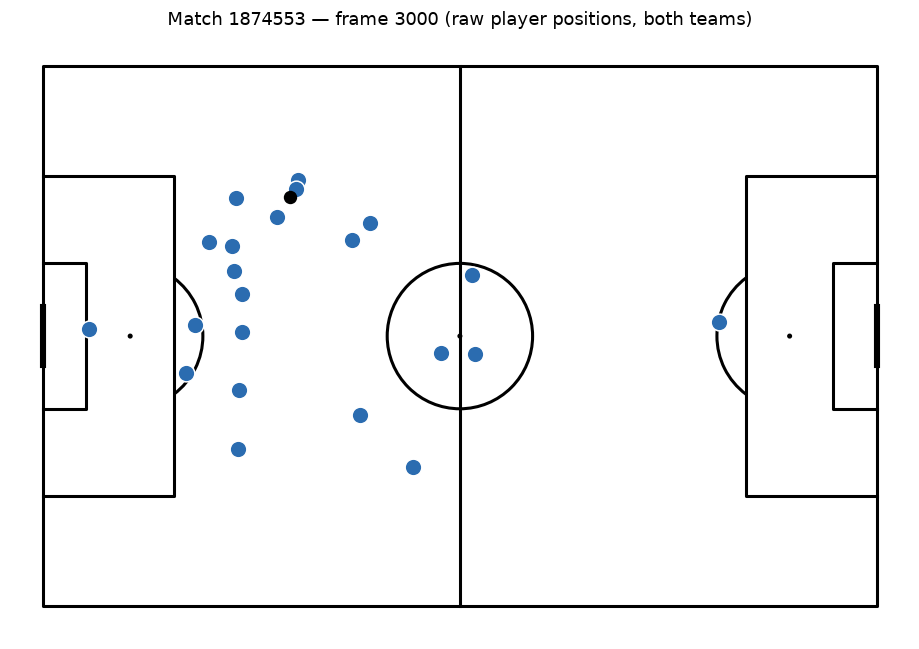

In [14]:
pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9, 6))

xs = [p["x"] for p in frame["player_data"]]
ys = [p["y"] for p in frame["player_data"]]
ax.scatter(xs, ys, s=120, color="#2b6cb0", edgecolors="white", zorder=3)

if frame["ball_data"]["x"] is not None:
    ax.scatter(frame["ball_data"]["x"], frame["ball_data"]["y"], s=60, color="black", zorder=4)

ax.set_title(f"Match {MATCH_IDS[0]} — frame {frame['frame']} (raw player positions, both teams)")
plt.show()


Positions load cleanly and land inside pitch bounds. This confirms tracking is usable for a
custom defensive-shape metric (e.g. convex hull area of the back line, or per-frame
nearest-opponent distance) if the phases-of-play precomputed width/length turns out to be too
coarse for the final question.

## 6. Candidate hypotheses

Ranked by how directly the data supports them and how useful the answer would be to an analyst
or coach — not just "is it measurable" but "would a real team change something based on the
result."

1. **Controlling for phase type and pitch zone, does defensive block compactness still predict
   shot risk?** (Section 3) — reframes the naive/confounded correlation into a real question.
   Directly actionable: "should we stay compact here, or is it about *where*, not *how tight*."
   Needs a proper model (logistic regression / gradient boosting on `team_possession_lead_to_shot`
   with phase type, zone, area, and possession length as features) rather than bivariate bars.

2. **Does pressing intensity (`on_ball_engagement` subtype, chain length) reduce the attacking
   team's possession value (`xloss_delta`), and is that consistent across teams/blocks, or do
   some teams press a lot with little payoff?** (Section 4) — a "press smarter, not just more"
   framing with a built-in team-comparison angle, useful for opposition scouting.

3. **Custom defensive-shape metric from raw tracking** (Section 5) — e.g. convex-hull area of
   the outfield block or last-line straightness, to check whether SkillCorner's width×length
   proxy misses shape distortions (e.g. a narrow-but-broken line) that matter more than raw area.
   Most original, most work; best as a secondary contribution layered onto (1) or (2) rather than
   a full pipeline given the ~1-2 month timeline.

**Leaning towards (1) as the spine of the submission**, with (2) as a complementary angle
(pressing effectiveness by team) if there's time, and (3) reserved as a validation/robustness
check rather than the whole project — it's the option that best fits the "Relevance" and
"Open-source potential" judging criteria: a reusable pattern (control for phase type before
trusting a shape metric) that other analysts working with this kind of data would hit too.
